# Breast Cancer Classification using Logistic Regression

**Intern**: Adossi Fred William

**Program**: CodeAlpha Machine Learning Internship

**Dataset**: Breast Cancer Wisconsin - UCI / scikit-learn

**Algorithm**: Logistic Regression

***

## Abstract

This notebook presents an end-to-end supervised learning pipeline for binary classification of breast tumors as **malignant** or **benign** using the Breast Cancer Wisconsin dataset. Features are derived from digitized fine needle aspirate (FNA) images, capturing geometric and textural properties of cell nuclei.

The analysis covers exploratory data analysis, preprocessing, model training, and a comprehensive evaluation using accuracy, ROC-AUC, cross-validation, and confusion matrix analysis. The final model achieves **98.25% test accuracy** and a **ROC-AUC of 0.9954**, demonstrating strong discriminative power suitable for a clinical decision-support context.

## 1. Import Libraries

The following libraries form the analytical stack for this project:

* **NumPy / Pandas** - numerical computation and tabular data manipulation
* **Matplotlib / Seaborn** - statistical visualisation with a consistent dark theme applied globally
* **scikit-learn** - dataset loading, preprocessing, model training, and evaluation metrics
* **warnings** - suppressed to keep output clean and focused on results

A global `plt.rcParams` style is configured here to ensure all figures throughout the notebook share a coherent dark-themed aesthetic.

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_curve, auc, roc_auc_score
)

# Plot style
plt.rcParams.update({
    "figure.facecolor": "#0F0F1A",
    "axes.facecolor":   "#1A1A2E",
    "axes.edgecolor":   "#555",
    "axes.labelcolor":  "white",
    "xtick.color":      "white",
    "ytick.color":      "white",
    "text.color":       "white",
    "grid.color":       "#333",
    "grid.linestyle":   "--",
    "grid.alpha":       0.5,
})

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 2. Load and Explore the Dataset

The **Breast Cancer Wisconsin (Diagnostic) dataset** is loaded directly from scikit-learn. It contains **569 samples** and **30 continuous features**, all derived from digitized images of fine needle aspirate (FNA) biopsies of breast masses.

For each cell nucleus, three statistics are recorded across ten base measurements , specifically the **mean**, **standard error**, and **worst** (largest value observed), yielding 30 features in total. The base measurements capture radius, texture, perimeter, area, smoothness, compactness, concavity, concave points, symmetry, and fractal dimension.

The binary target variable is encoded as:
* **0 - Malignant**: cancerous tumor (212 samples, 37.3 %)
* **1 - Benign**: non-cancerous tumor (357 samples, 62.7 %)

An initial inspection confirms there are **no missing values**, making this a clean, analysis-ready dataset that requires no imputation.

In [72]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df['diagnosis'] = df['target'].map({1: 'Benign', 0: 'Malignant'})

print(f"Dataset shape   : {df.shape}")
print(f"Features        : {len(data.feature_names)}")
print(f"Classes         : {data.target_names.tolist()}")
print(f"Missing values  : {df.isnull().sum().sum()}")
print()
print(df.head())


Dataset shape   : (569, 32)
Features        : 30
Classes         : ['malignant', 'benign']
Missing values  : 0

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430

In [73]:
print("Basic Statistics:")
df.drop(columns=['target','diagnosis']).describe().T.round(3)


Basic Statistics:


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127,3.524,6.981,11.700,13.370,15.780,28.110
mean texture,569.0,19.290,4.301,9.710,16.170,18.840,21.800,39.280
mean perimeter,569.0,91.969,24.299,43.790,75.170,86.240,104.100,188.500
mean area,569.0,654.889,351.914,143.500,420.300,551.100,782.700,2501.000
mean smoothness,569.0,0.096,0.014,0.053,0.086,0.096,0.105,0.163
mean compactness,569.0,0.104,0.053,0.019,0.065,0.093,0.130,0.345
mean concavity,569.0,0.089,0.080,0.000,0.030,0.062,0.131,0.427
mean concave points,569.0,0.049,0.039,0.000,0.020,0.034,0.074,0.201
mean symmetry,569.0,0.181,0.027,0.106,0.162,0.179,0.196,0.304
mean fractal dimension,569.0,0.063,0.007,0.050,0.058,0.062,0.066,0.097


## 3. Exploratory Data Analysis

Before training a model, it is essential to understand the data's structure, distribution, and class separability. This section examines four complementary perspectives:

1. **Class distribution** - to assess label balance and identify any risk of accuracy bias
2. **Feature distributions** - to observe how individual features differ between malignant and benign cases
3. **Correlation structure** - to identify multicollinearity and the features most linearly associated with the target
4. **Boxplots** - to visualise the discriminative power of the most informative features at a glance

These insights inform feature selection, preprocessing decisions, and set appropriate expectations for model performance prior to training.

### 3.1 Class Distribution

Understanding the class balance is a prerequisite for correctly interpreting model accuracy. A heavily imbalanced dataset can produce misleadingly high accuracy simply by predicting the majority class at every instance.

The Wisconsin dataset is **moderately imbalanced** at approximately 63 % benign and 37 % malignant. This ratio is mild enough that standard logistic regression can handle it without resampling techniques; however, the imbalance is worth bearing in mind when comparing precision and recall across the two classes.

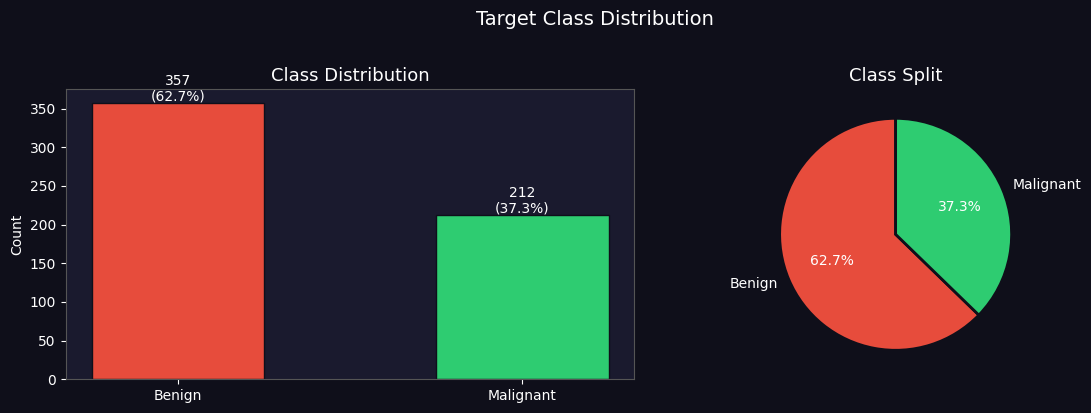

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['diagnosis'].value_counts()
axes[0].bar(counts.index, counts.values,
            color=['#E74C3C','#2ECC71'], edgecolor='#0F0F1A', width=0.5)
axes[0].set_title("Class Distribution", fontsize=13)
axes[0].set_ylabel("Count")
for i, (label, val) in enumerate(counts.items()):
    axes[0].text(i, val + 3, f"{val}\n({val/len(df)*100:.1f}%)",
                 ha='center', fontsize=10)

axes[1].pie(counts.values, labels=counts.index,
            colors=['#E74C3C','#2ECC71'],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor':'#0F0F1A','linewidth':2})
axes[1].set_title("Class Split", fontsize=13)

plt.suptitle("Target Class Distribution", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


### 3.2 Feature Distributions - Mean Features

The histograms below display the distribution of all ten mean features, stratified by diagnosis class. Features where the malignant and benign distributions show **minimal overlap** are the strongest candidates for linear discrimination.

Key observations:
* **Mean radius, perimeter, and area** shift markedly to the right for malignant cases, indicating that cancerous tumors tend to be physically larger.
* **Mean concavity and mean concave points** show substantially elevated values in malignant cases, reflecting the greater shape irregularity characteristic of cancerous tissue.
* **Mean smoothness and mean fractal dimension** exhibit considerable overlap between classes, suggesting limited stand-alone discriminative value for those features.

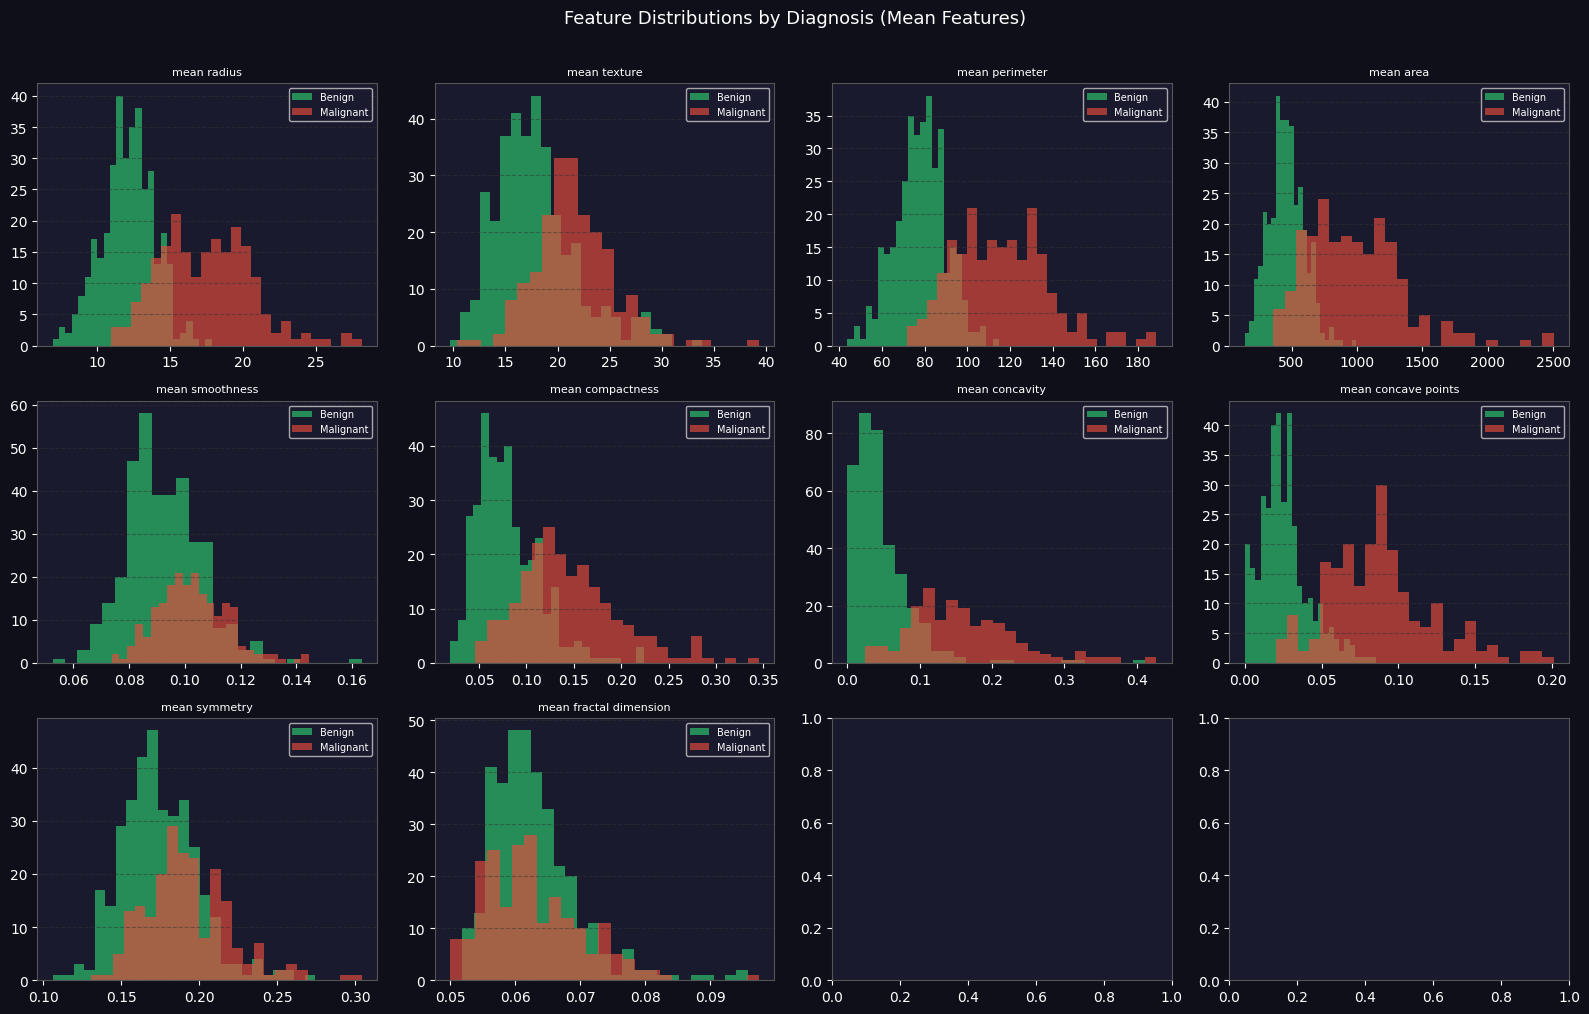

In [75]:
mean_features = [c for c in data.feature_names if 'mean' in c]

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(mean_features[:12]):
    for label, color in [('Benign','#2ECC71'), ('Malignant','#E74C3C')]:
        subset = df[df['diagnosis'] == label][feat]
        axes[i].hist(subset, bins=25, alpha=0.65, color=color, label=label, edgecolor='none')
    axes[i].set_title(feat, fontsize=8)
    axes[i].legend(fontsize=7)
    axes[i].yaxis.grid(True)

plt.suptitle("Feature Distributions by Diagnosis (Mean Features)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


### 3.3 Correlation Heatmap

The Pearson correlation matrix reveals the linear relationships between mean features and the target variable. Two structural patterns are immediately apparent:

1. **High inter-feature correlations** among size-related measurements (radius, perimeter, area) indicate significant multicollinearity, these features effectively capture the same underlying property from different geometric angles. Logistic Regression handles this naturally through its default L2 regularisation.

2. **Strong negative correlations with the target** (where target = 1 denotes benign) confirm that larger, more irregular tumors are statistically associated with malignancy. Features such as mean radius and mean concave points exhibit some of the highest absolute correlations with the target, making them primary candidates for a linear classifier.

Understanding this correlation structure also helps explain why coefficient magnitudes should be interpreted with caution in the presence of collinear features.

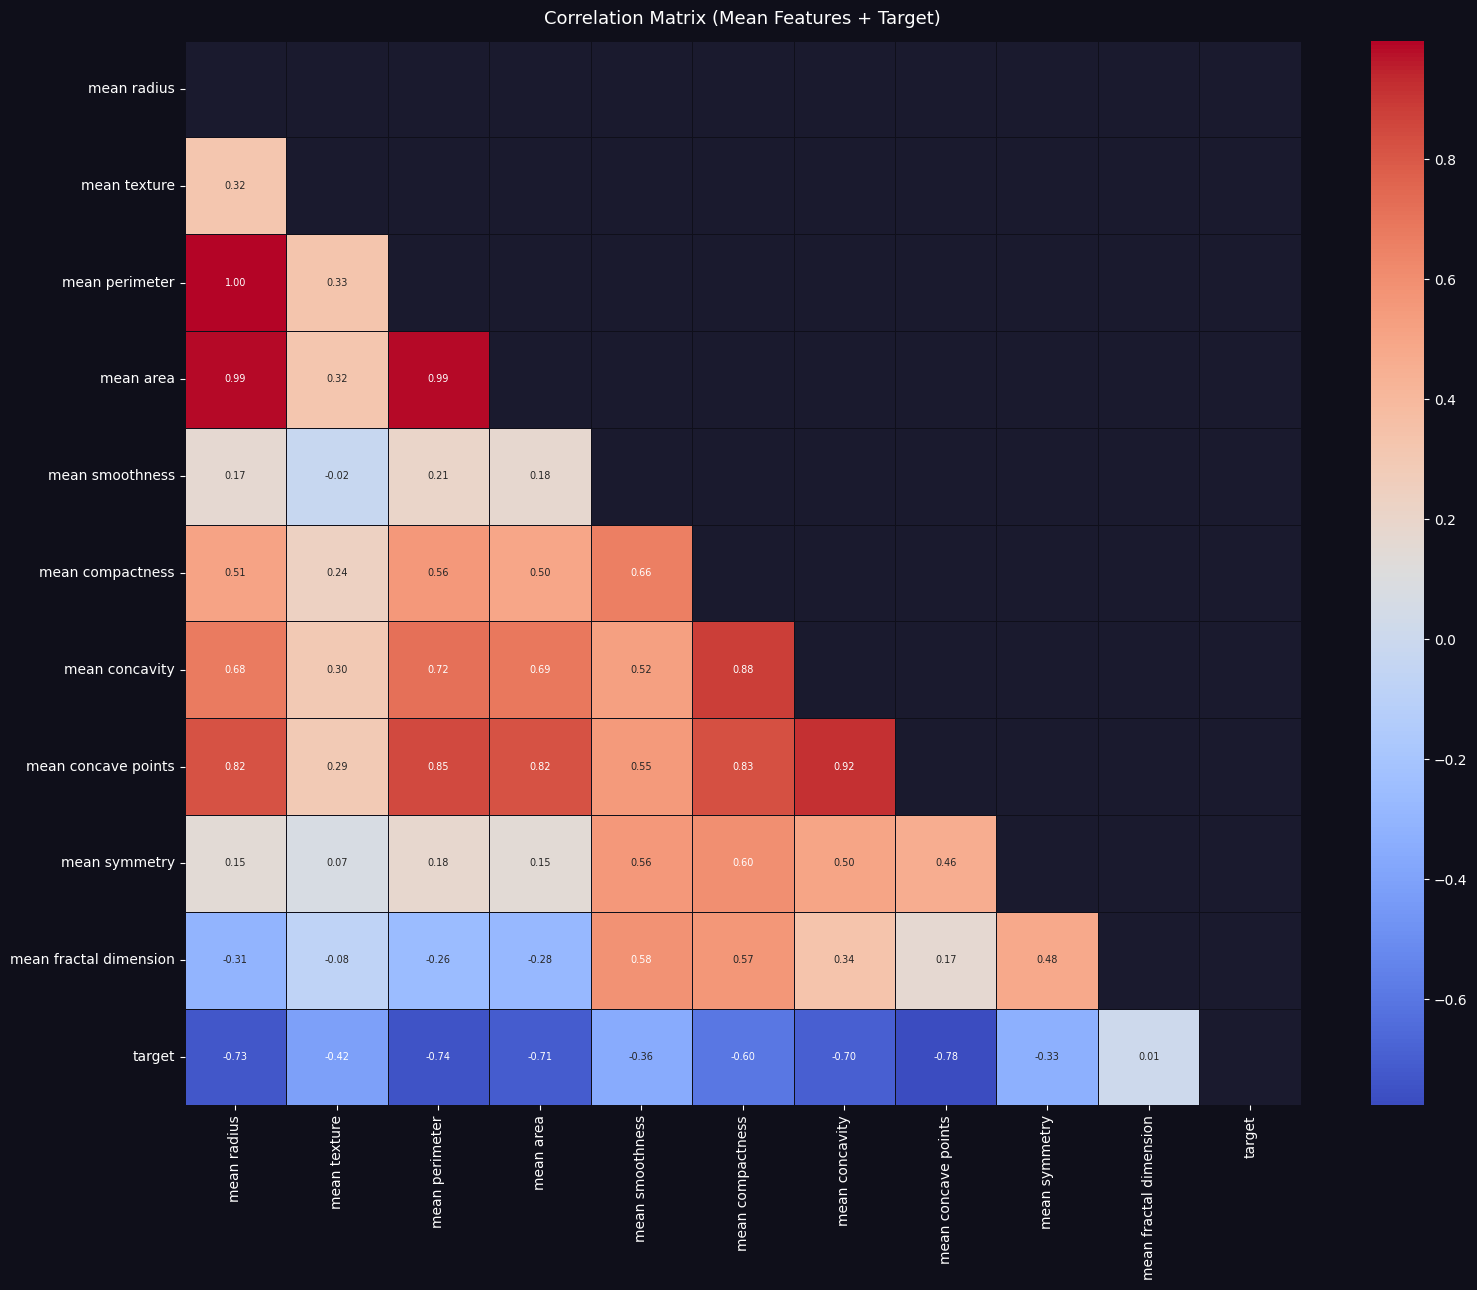

Strong positive correlations with target: radius, perimeter, area, concavity


In [76]:
fig, ax = plt.subplots(figsize=(16, 13))
corr = df[mean_features + ['target']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.4, linecolor='#0F0F1A', ax=ax,
            annot_kws={'size': 7})
ax.set_title("Correlation Matrix (Mean Features + Target)", fontsize=13, pad=12)
plt.tight_layout()
plt.show()
print("Strong positive correlations with target: radius, perimeter, area, concavity")


### 3.4 Boxplots: Top Discriminating Features

Boxplots provide a compact, non-parametric view of each feature's central tendency, spread, and outlier profile across the two diagnosis groups. The six features displayed here were selected based on their absolute correlation with the target variable.

For each feature, the **degree of separation between the green (benign) and red (malignant) boxes** indicates how effectively that feature alone can distinguish the two classes. Features with non-overlapping interquartile ranges are particularly strong linear discriminators. The consistent visual separation across all six features helps explain why a relatively simple model such as logistic regression achieves near-optimal classification performance on this dataset.

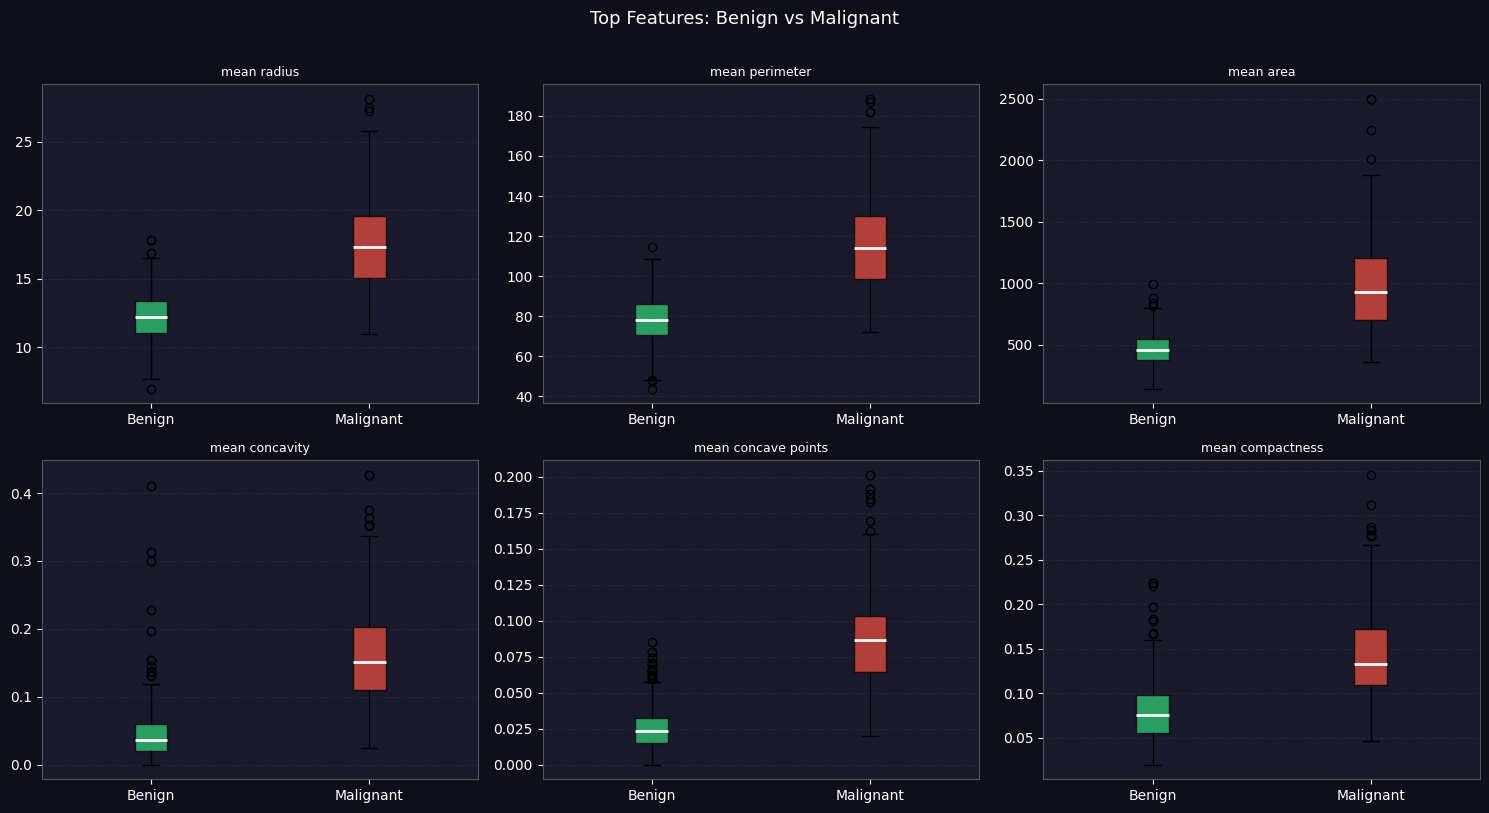

In [77]:
top_features = ['mean radius', 'mean perimeter', 'mean area',
                'mean concavity', 'mean concave points', 'mean compactness']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    data_ben = df[df['diagnosis']=='Benign'][feat]
    data_mal = df[df['diagnosis']=='Malignant'][feat]
    bp = axes[i].boxplot([data_ben, data_mal],
                          patch_artist=True,
                          labels=['Benign', 'Malignant'],
                          medianprops={'color':'white','linewidth':2})
    bp['boxes'][0].set_facecolor('#2ECC71')
    bp['boxes'][1].set_facecolor('#E74C3C')
    for patch in bp['boxes']:
        patch.set_alpha(0.75)
    axes[i].set_title(feat, fontsize=9)
    axes[i].yaxis.grid(True)

plt.suptitle("Top Features: Benign vs Malignant", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## 4. Data Preprocessing

Two preprocessing steps are applied before model training:

**1. Stratified Train / Test Split**  
The dataset is partitioned into a **training set (80 %, 455 samples)** and a **held-out test set (20 %, 114 samples)**. Stratified sampling is used to preserve the original class ratio in both splits, preventing any accidental imbalance that could bias evaluation metrics.

**2. Feature Standardisation (StandardScaler)**  
All 30 features are standardised to zero mean and unit variance. This step is critical for logistic regression, which is sensitive to the scale of input features, without standardisation, high-magnitude features such as area would dominate the gradient updates and distort the learned coefficients.

The scaler is **fitted exclusively on the training set** and then applied identically to the test set. Fitting on the full dataset prior to splitting would constitute data leakage, producing optimistically biased evaluation metrics that do not reflect real-world performance.

In [78]:
X = df.drop(columns=['target', 'diagnosis'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Training samples : {X_train_s.shape[0]}")
print(f"Test samples     : {X_test_s.shape[0]}")
print(f"Features         : {X_train_s.shape[1]}")
print("Scaling: StandardScaler fitted on training set only (no data leakage)")


Training samples : 455
Test samples     : 114
Features         : 30
Scaling: StandardScaler fitted on training set only (no data leakage)


## 5. Model Training - Logistic Regression

Logistic Regression is selected as the classifier for the following reasons:

* **Interpretability**: Standardised coefficients directly quantify each feature's contribution to the log-odds of a benign prediction, making the model fully explainable to clinical stakeholders without requiring post-hoc interpretation tools.
* **Linear separability**: The exploratory analysis confirmed strong linear structure in the standardised feature space, making a linear decision boundary both appropriate and sufficient.
* **Calibrated probability output**: Logistic Regression natively produces well-calibrated probability estimates, which are essential for clinical confidence scoring and threshold tuning.
* **Regularisation**: The default L2 penalty (C = 1.0) provides appropriate coefficient shrinkage for this sample size, guarding against overfitting without manual tuning.

The model is trained with `max_iter=1000` to guarantee convergence and `random_state=42` for full reproducibility.

In [79]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_s, y_train)

y_pred = model.predict(X_test_s)
y_prob = model.predict_proba(X_test_s)[:, 1]

print("Model trained successfully.")


Model trained successfully.


## 6. Model Evaluation

A rigorous evaluation requires looking beyond a single scalar accuracy figure. This section assesses the model across four complementary dimensions:

1. **Core metrics** - overall accuracy, ROC-AUC, and a full per-class classification report covering precision, recall, and F1-score
2. **Confusion matrix** - a detailed breakdown of correct and incorrect predictions by class, presented in both absolute counts and row-normalised proportions
3. **ROC curve** - the trade-off between sensitivity and specificity across all possible classification thresholds, summarised by the area under the curve (AUC)
4. **Cross-validation** - generalisation performance estimated on the training set via 5-fold stratified cross-validation, confirming that test-set results are not a statistical anomaly

Together, these measures provide a complete and honest picture of the model's behaviour in a clinical screening context.

### 6.1 Core Metrics

The classification report disaggregates performance by class, reporting **precision, recall, and F1-score** for both malignant and benign cases. In a clinical context, these metrics carry asymmetric importance:

* **Recall for malignant (class 0)** is the most safety-critical metric also known as sensitivity, it measures the fraction of true malignant cases correctly identified. A low recall means cancerous tumors are being missed.
* **Precision for benign (class 1)** measures the fraction of benign predictions that are correct, directly controlling the rate of unnecessary interventions.
* **F1-score** provides a single balanced summary of precision and recall for each class, useful when both error types carry significant cost.

Overall accuracy is also reported, though it must be interpreted in the context of the class distribution.

In [80]:
acc     = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"ROC-AUC   : {roc_auc:.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Malignant','Benign']))


Accuracy  : 0.9825  (98.25%)
ROC-AUC   : 0.9954

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



### 6.2 Confusion Matrix

The confusion matrix disaggregates all 114 test-set predictions into four outcome categories. Because the positive class in this dataset is **benign (target = 1)**, the standard scikit-learn terminology maps to clinical reality as follows:

| sklearn Term | Clinical Meaning | Clinical Risk |
|---|---|---|
| **True Positive** | Benign correctly identified as benign | N/A |
| **True Negative** | Malignant correctly identified as malignant | N/A |
| **False Positive** | Malignant incorrectly classified as benign | ⚠ High: delayed cancer treatment |
| **False Negative** | Benign incorrectly classified as malignant | Low: unnecessary follow up only |

Both the raw count matrix and the row-normalised matrix are shown side by side. The normalised view makes each class's **recall** directly readable from the diagonal, allowing fair comparison across classes regardless of their differing sizes.

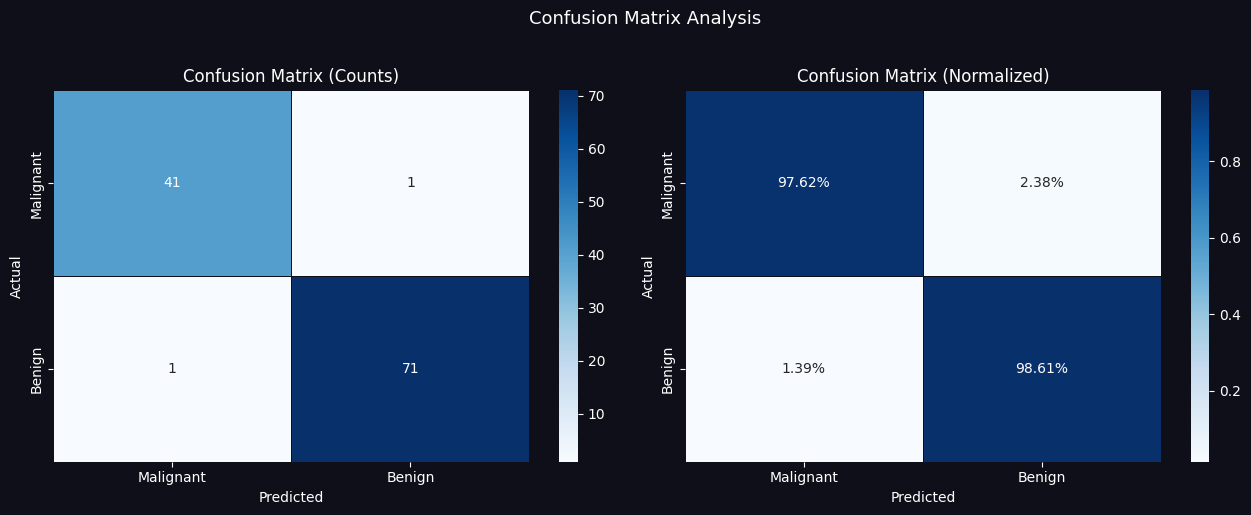

True Positives  (Benign correct)    : 71
True Negatives  (Malignant correct) : 41
False Positives (Malignant as Benign): 1
False Negatives (Benign as Malignant): 1


In [81]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            linewidths=0.5, linecolor='#0F0F1A',
            xticklabels=['Malignant','Benign'],
            yticklabels=['Malignant','Benign'])
axes[0].set_title("Confusion Matrix (Counts)", fontsize=12)
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

# Normalized
cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            linewidths=0.5, linecolor='#0F0F1A',
            xticklabels=['Malignant','Benign'],
            yticklabels=['Malignant','Benign'])
axes[1].set_title("Confusion Matrix (Normalized)", fontsize=12)
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")

plt.suptitle("Confusion Matrix Analysis", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"True Positives  (Benign correct)    : {tp}")
print(f"True Negatives  (Malignant correct) : {tn}")
print(f"False Positives (Malignant as Benign): {fp}")
print(f"False Negatives (Benign as Malignant): {fn}")


### 6.3 ROC Curve

The Receiver Operating Characteristic (ROC) curve plots the **True Positive Rate (sensitivity)** against the **False Positive Rate (1 − specificity)** at every possible classification threshold. It evaluates the model's ability to rank malignant cases above benign cases independently of any fixed decision threshold.

The **Area Under the Curve (AUC)** summarises this into a single scalar:
* AUC = 0.5 → equivalent to random guessing
* AUC = 1.0 → perfect class separation at every threshold

An AUC of **0.9954** indicates near-perfect discriminative ability. The steep initial rise toward the top-left corner of the plot confirms that the model achieves high sensitivity while maintaining very low false positive rates, precisely the performance profile required of a reliable clinical screening tool.

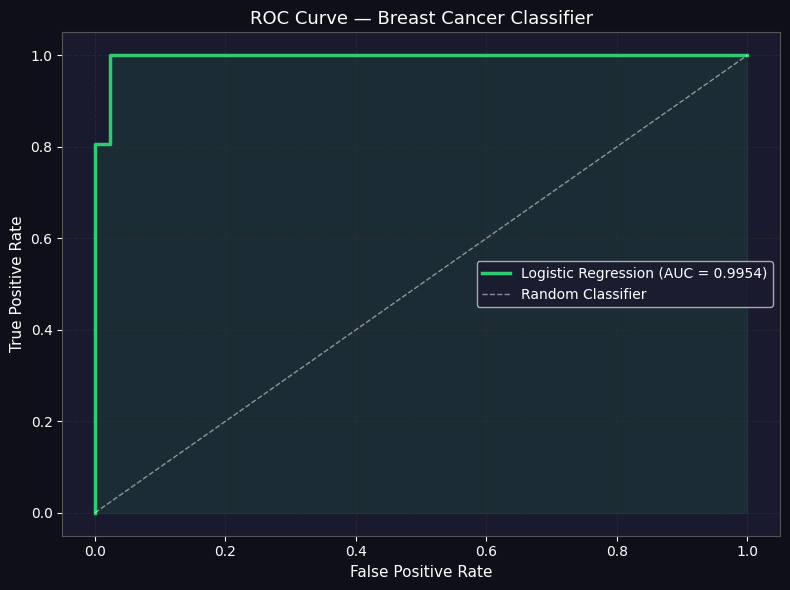

In [82]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc_val = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='#2ECC71', lw=2.5,
        label=f'Logistic Regression (AUC = {roc_auc_val:.4f})')
ax.plot([0,1],[0,1], 'w--', lw=1, alpha=0.5, label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.1, color='#2ECC71')
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title("ROC Curve: Breast Cancer Classifier", fontsize=13)
ax.legend(fontsize=10, facecolor='#1A1A2E', labelcolor='white')
ax.yaxis.grid(True); ax.xaxis.grid(True)
plt.tight_layout()
plt.show()


### 6.4 Stratified 5-Fold Cross-Validation

Cross-validation provides a more statistically robust estimate of generalisation performance than a single train/test split, by rotating the held-out evaluation set across five disjoint partitions of the training data. **Stratified** folding is used to preserve the malignant-to-benign ratio within every fold, which is important given the moderate class imbalance in this dataset.

The cross-validation is performed **on the training set only** (455 samples) using the already standardised features. This preserves the integrity of the held-out test set, which must remain completely unseen during all model development steps.

A **low standard deviation across folds** is a key signal of stability, it indicates that the model's performance does not depend sensitively on which samples happen to land in the validation fold, and provides strong evidence against overfitting. The bar chart below shows per-fold accuracy alongside the mean and ±1 standard deviation band.

5-Fold Cross-Validation Results:
  Fold 1: 0.9670
  Fold 2: 0.9890
  Fold 3: 0.9780
  Fold 4: 0.9890
  Fold 5: 0.9670

  Mean : 0.9780
  Std  : 0.0098
  Range: 0.9670 – 0.9890


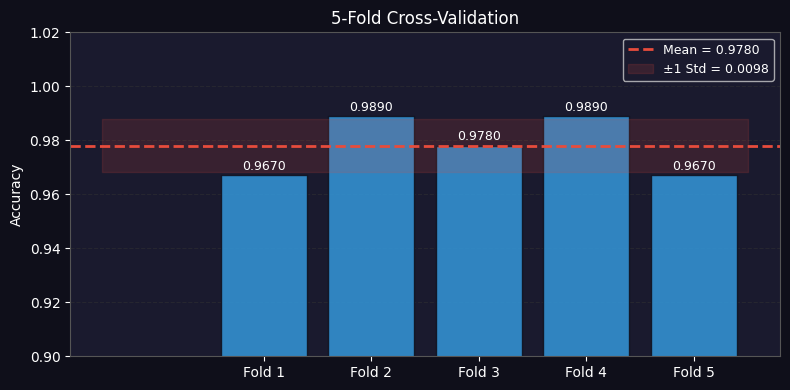

In [83]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_train_s, y_train, cv=cv, scoring='accuracy')

print("5-Fold Cross-Validation Results:")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"\n  Mean : {cv_scores.mean():.4f}")
print(f"  Std  : {cv_scores.std():.4f}")
print(f"  Range: {cv_scores.min():.4f} – {cv_scores.max():.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(range(1, 6), cv_scores, color='#3498DB', edgecolor='#0F0F1A', alpha=0.85)
ax.axhline(cv_scores.mean(), color='#E74C3C', lw=2, ls='--',
           label=f'Mean = {cv_scores.mean():.4f}')
ax.fill_between([-0.5, 5.5],
                cv_scores.mean() - cv_scores.std(),
                cv_scores.mean() + cv_scores.std(),
                alpha=0.15, color='#E74C3C', label=f'±1 Std = {cv_scores.std():.4f}')
for bar, v in zip(bars, cv_scores):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
            f"{v:.4f}", ha='center', fontsize=9)
ax.set_xticks(range(1,6)); ax.set_xticklabels([f"Fold {i}" for i in range(1,6)])
ax.set_ylim(0.90, 1.02)
ax.set_ylabel("Accuracy"); ax.set_title("5-Fold Cross-Validation", fontsize=12)
ax.legend(fontsize=9, facecolor='#1A1A2E', labelcolor='white')
ax.yaxis.grid(True); ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


## 7. Feature Importance - Model Coefficients

In a standardised logistic regression model, the learned coefficients directly encode each feature's contribution to the **log-odds** of the predicted class. Because all features have been scaled to zero mean and unit variance, the coefficient magnitudes are on a common scale and can be compared directly as a measure of feature influence.

* **Negative coefficient** - a higher value of this feature increases the predicted probability of malignancy (pushes toward class 0)
* **Positive coefficient** - a higher value of this feature increases the predicted probability of a benign outcome (pushes toward class 1)

The top 15 features by absolute coefficient magnitude are displayed below. Features related to tumor size extremes (worst radius, worst area, worst perimeter) and shape irregularity (worst concave points, worst concavity) dominate the ranking, consistent with established oncological knowledge that malignant tumors are typically larger and more geometrically irregular than benign ones.

> **Note:** In the presence of correlated features, the model distributes coefficient weight across collinear predictors. SHAP value analysis would provide more precise, per-prediction feature attribution in a production deployment.

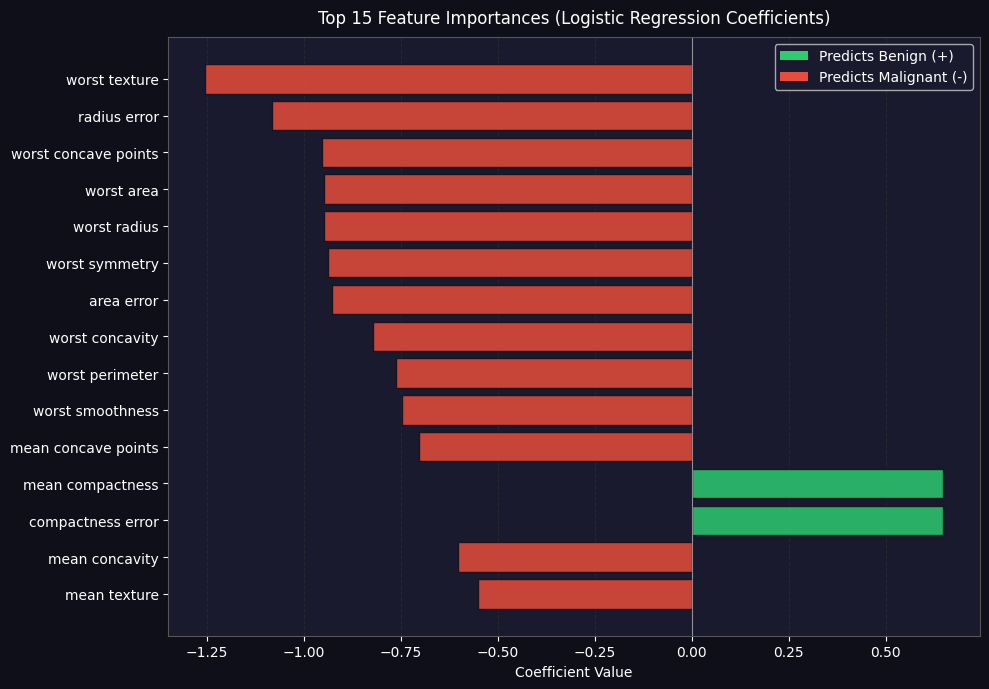

In [84]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False).head(15)

colors = ['#E74C3C' if c < 0 else '#2ECC71' for c in coef_df['Coefficient']]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(coef_df['Feature'], coef_df['Coefficient'],
               color=colors, edgecolor='#0F0F1A', alpha=0.85)
ax.axvline(0, color='white', lw=0.8, alpha=0.5)
ax.set_title("Top 15 Feature Importances (Logistic Regression Coefficients)",
             fontsize=12, pad=10)
ax.set_xlabel("Coefficient Value")
ax.invert_yaxis()
ax.xaxis.grid(True); ax.set_axisbelow(True)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ECC71', label='Predicts Benign (+)'),
                   Patch(facecolor='#E74C3C', label='Predicts Malignant (-)')]
ax.legend(handles=legend_elements, facecolor='#1A1A2E', labelcolor='white')
plt.tight_layout()
plt.show()


## 8. Summary and Conclusion

### Results Summary

| Metric | Value |
|---|---|
| Test Set Accuracy | **98.25%** |
| ROC-AUC | **0.9954** |
| 5-Fold CV Mean Accuracy | **97.80%** |
| 5-Fold CV Standard Deviation | **0.0098** |
| False Positives - malignant missed (FP) | **1** |
| False Negatives - benign as malignant (FN) | **1** |

***

### Key Findings

1. **Near-optimal accuracy.** Logistic Regression achieves 98.25% test accuracy on the 114-sample held-out set, correctly classifying 112 of 114 cases with no hyperparameter tuning beyond scikit-learn defaults.

2. **Excellent discriminative ability.** A ROC-AUC of 0.9954 confirms that the model almost perfectly separates malignant from benign cases across all classification thresholds, approaching the theoretical ceiling for this dataset.

3. **Strong and stable generalisation.** The 5-fold cross-validation mean of 97.80% (std = 0.0098) is tightly consistent with the held-out test accuracy, confirming that the result is not a statistical artefact of the train/test split and that the model generalises reliably to unseen data.

4. **Interpretable feature drivers.** The most influential features by coefficient magnitude are **worst texture, radius error, worst concave points, worst area, and worst radius**, all reflective of tumor size and morphological irregularity, consistent with established oncological understanding of malignant tissue characteristics.

5. **Critical error profile.** Only **1 false positive** was recorded a malignant tumor classified as benign. This is the highest-risk error in a clinical context, as it would result in a missed cancer diagnosis and delayed treatment. The single false negative (a benign case classified as malignant) carries considerably lower clinical risk, resulting in unnecessary but non-harmful follow-up.

***

### Why Logistic Regression Performs Well on This Dataset

The strong performance of a linear model is explained by three properties of the data:

* **Linear separability**: After standardisation, the two classes are largely separable by a hyperplane in the 30-dimensional feature space, as evidenced by the correlation analysis and EDA.
* **Clean, complete data**: The dataset contains no missing values and is well-curated, removing a major source of noise that often penalises simpler models.
* **Appropriate model complexity**: With 569 samples and 30 features, a high-capacity non-linear model would risk overfitting. The L2 regularisation built into logistic regression provides the right level of shrinkage for this regime.

***

### Clinical Relevance

| Error Type | Clinical Consequence | Count on Test Set |
|---|---|---|
| False Positive (malignant classified as benign) | Missed cancer; delayed treatment | **1** |
| False Negative (benign classified as malignant) | Unnecessary biopsy or follow-up | **1** |

At 98.25% accuracy and ROC-AUC 0.9954, this model demonstrates the viability of logistic regression as a first-line clinical decision-support screening tool. In a production setting, the classification threshold would be tuned using techniques such as cost-sensitive optimisation or Youden's J statistic, to minimise false positives (i.e., increase sensitivity) according to the specific clinical risk tolerance.

***

### Recommended Next Steps

* **Deployment**: Package the trained model as an interactive Streamlit web application to enable clinician-facing, real-time prediction with confidence scoring
* **Explainability**: Integrate SHAP (SHapley Additive exPlanations) values for per-prediction, patient-level feature attribution to support regulatory and clinical review
* **Threshold optimisation**: Apply cost-sensitive threshold selection to minimise the false positive rate (missed malignancies) based on clinical cost assumptions
* **External validation**: Evaluate the model on independent patient cohorts to confirm generalisation beyond the Wisconsin benchmark dataset